# Proyecto 2 — Análisis Exploratorio de Datos

## Reto #11: Predicción de compradores recurrentes: cuestionar la línea base

**CC3084 – Data Science | Universidad del Valle de Guatemala | Semestre II – 2026**

**David Dominguez - 23712**
**Gabriel Bran - 23590**
**Luis Padilla - 23663**


---

### Alcance

Este notebook contiene un **análisis exploratorio de datos (EDA)** completo sobre el conjunto de datos de la competencia *Repeat Buyers Prediction* de la plataforma Tianchi (Alibaba). **No se entrenan modelos predictivos** en este proyecto.

### Pregunta de análisis

> ¿Qué patrones de comportamiento de compra y características demográficas se asocian con que un usuario de la plataforma Tmall vuelva a comprar a un mismo vendedor?

### Enlace al reto original

[Tianchi — Repeat Buyers Prediction](https://tianchi.aliyun.com/competition/entrance/231576/information)

## 2. Configuración

In [ ]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
import gc

# Suprimir advertencias innecesarias
warnings.filterwarnings('ignore')

# Semilla para reproducibilidad
np.random.seed(42)

# --- Rutas del proyecto, resueltas desde la raíz real del repositorio ---
def _find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / 'data' / 'data_format1').exists():
            return candidate
    return current

PROJECT_ROOT = _find_project_root()
DATA_DIR = PROJECT_ROOT / 'data' / 'data_format1'
TRAIN_PATH = DATA_DIR / 'train_format1.csv'
TEST_PATH = DATA_DIR / 'test_format1.csv'
USER_INFO_PATH = DATA_DIR / 'user_info_format1.csv'
USER_LOG_PATH = DATA_DIR / 'user_log_format1.csv'
SAMPLE_SUB_PATH = PROJECT_ROOT / 'data' / 'sample_submission.csv'

FIG_DIR = PROJECT_ROOT / 'outputs' / 'figures'
TAB_DIR = PROJECT_ROOT / 'outputs' / 'tables'

# --- Crear directorios de salida ---
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)

# --- Configuración visual ---
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'figure.dpi': 150,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
sns.set_style('whitegrid')
PALETTE = sns.color_palette('Set2')
COLOR_0 = PALETTE[1]  # No recurrente
COLOR_1 = PALETTE[0]  # Recurrente
labels_map = {0: 'No recurrente', 1: 'Recurrente'}


def normalize_age_range(series: pd.Series) -> pd.Series:
    """Conserva 0 como desconocido y colapsa 7/8 en 50+."""
    return series.fillna(0).replace({8: 7}).astype(int)


age_labels = {
    0: 'Desconocido',
    1: '<18',
    2: '18-24',
    3: '25-29',
    4: '30-34',
    5: '35-39',
    6: '40-49',
    7: '50+',
}
gender_labels = {0: 'Femenino', 1: 'Masculino', 2: 'Desconocido'}

print("Configuración completada.")

✓ Configuración completada.


## 3. Verificación de archivos

In [ ]:
archivos = {
    'Entrenamiento': TRAIN_PATH,
    'Prueba': TEST_PATH,
    'Información de usuarios': USER_INFO_PATH,
    'Registro de actividad': USER_LOG_PATH,
    'Envío de muestra': SAMPLE_SUB_PATH,
}

print(f"{'Archivo':<30} {'Existe':<8} {'Tamaño (MB)':>12}")
print("-" * 55)
for nombre, ruta in archivos.items():
    existe = os.path.isfile(ruta)
    if existe:
        tam = os.path.getsize(ruta) / (1024 ** 2)
        print(f"{nombre:<30} {'Sí':<8} {tam:>10.1f} MB")
    else:
        print(f"{nombre:<30} {'NO':<8} {'---':>12}")

print()
print(" NOTA: El archivo de registro de actividad (user_log_format1.csv)")
print("   ocupa aproximadamente 1.9 GB y contiene ~55 millones de filas.")
print("   Se procesará mediante lectura por fragmentos (chunks).")

Archivo                        Existe    Tamaño (MB)
-------------------------------------------------------
Entrenamiento                  Sí              3.4 MB
Prueba                         Sí              3.1 MB
Información de usuarios        Sí              4.3 MB
Registro de actividad          Sí           1821.7 MB
Envío de muestra               Sí              3.9 MB

⚠️  NOTA: El archivo de registro de actividad (user_log_format1.csv)
   ocupa aproximadamente 1.9 GB y contiene ~55 millones de filas.
   Se procesará mediante lectura por fragmentos (chunks).


## 4. Carga de datos

Los archivos pequeños (`train`, `test`, `user_info`) se cargan completos en memoria.
El archivo de registros de actividad (`user_log`) contiene ~55 millones de filas (~1.9 GB),
por lo que se procesa mediante lectura por fragmentos (`chunksize`) para evitar problemas de memoria.

### 4.1 Carga de archivos pequeños

In [3]:
# Cargar train, test, user_info
train_raw = pd.read_csv(TRAIN_PATH)
test_raw = pd.read_csv(TEST_PATH)
user_info_raw = pd.read_csv(USER_INFO_PATH)

print(f"train_format1:     {train_raw.shape[0]:>10,} filas × {train_raw.shape[1]} columnas")
print(f"test_format1:      {test_raw.shape[0]:>10,} filas × {test_raw.shape[1]} columnas")
print(f"user_info_format1: {user_info_raw.shape[0]:>10,} filas × {user_info_raw.shape[1]} columnas")

train_format1:        260,864 filas × 3 columnas
test_format1:         261,477 filas × 3 columnas
user_info_format1:    424,170 filas × 3 columnas


### 4.2 Procesamiento del registro de actividad (user_log)

Dado el tamano del archivo (~55 millones de filas), se procesa en dos pasos para evitar cargarlo completo en memoria.

**Estrategia exacta**: cada fila se asigna a una particion en disco segun `hash(user_id, seller_id) mod N`. Asi, todos los registros de un mismo par quedan en la misma particion. Luego cada particion se agrupa completa por `(user_id, seller_id)` para calcular:
- Conteos de cada tipo de accion (clics, carrito, compras, favoritos)
- Total de acciones
- Conteo de valores unicos de productos, categorias, marcas y dias

Este enfoque es exacto, porque ningun par usuario-vendedor se divide entre particiones, y sigue siendo eficiente porque solo se carga una particion a la vez.

In [4]:
import shutil

CHUNKSIZE = 2_000_000
N_PARTITIONS = 128
PAIR_COLS = ['user_id', 'seller_id']
LOG_COLUMNS = ['user_id', 'seller_id', 'action_type', 'item_id', 'cat_id', 'brand_id', 'time_stamp']
LOG_DTYPE = {
    'user_id': 'int32',
    'seller_id': 'int32',
    'action_type': 'int8',
    'item_id': 'int32',
    'cat_id': 'int32',
    'brand_id': 'float64',
    'time_stamp': 'int16',
}

LOG_TMP_DIR = PROJECT_ROOT / 'outputs' / 'tmp' / 'user_log_partitions'
if LOG_TMP_DIR.exists():
    shutil.rmtree(LOG_TMP_DIR)
LOG_TMP_DIR.mkdir(parents=True, exist_ok=True)

part_files = [LOG_TMP_DIR / f'part_{i:03d}.csv' for i in range(N_PARTITIONS)]
written_headers = [False] * N_PARTITIONS

print('Dispersando user_log_format1.csv en particiones exactas...')
print(f'Fragmento de lectura: {CHUNKSIZE:,} filas')
print(f'Particiones en disco: {N_PARTITIONS}\n')

total_rows = 0
chunk_num = 0

for chunk in pd.read_csv(USER_LOG_PATH, usecols=LOG_COLUMNS, dtype=LOG_DTYPE, chunksize=CHUNKSIZE):
    chunk_num += 1
    total_rows += len(chunk)

    partitions = (
        pd.util.hash_pandas_object(chunk[PAIR_COLS], index=False)
        .to_numpy(dtype='uint64', copy=False) % N_PARTITIONS
    ).astype(np.int16)
    chunk['_partition'] = partitions

    for part_id, part_chunk in chunk.groupby('_partition', sort=False):
        part_id = int(part_id)
        output_path = part_files[part_id]
        part_chunk = part_chunk.drop(columns='_partition')
        part_chunk.to_csv(
            output_path,
            index=False,
            mode='a',
            header=not written_headers[part_id],
        )
        written_headers[part_id] = True

    print(
        f'  Fragmento {chunk_num:>3}: {total_rows:>12,} filas acumuladas '
        f'({total_rows / 54_925_330 * 100:>5.1f}%)'
    )

print('\nAgrupando particiones exactas por par usuario-vendedor...')

log_parts = []
rows_from_partitions = 0

for part_id, part_path in enumerate(part_files, start=1):
    if not part_path.exists() or part_path.stat().st_size == 0:
        continue

    part = pd.read_csv(part_path, dtype=LOG_DTYPE)
    rows_from_partitions += len(part)

    part['is_click'] = (part['action_type'] == 0).astype(np.int32)
    part['is_cart'] = (part['action_type'] == 1).astype(np.int32)
    part['is_purchase'] = (part['action_type'] == 2).astype(np.int32)
    part['is_favorite'] = (part['action_type'] == 3).astype(np.int32)

    agg = part.groupby(PAIR_COLS, as_index=False).agg(
        clicks=('is_click', 'sum'),
        cart=('is_cart', 'sum'),
        purchase=('is_purchase', 'sum'),
        favorite=('is_favorite', 'sum'),
        total_actions=('action_type', 'size'),
        n_items=('item_id', 'nunique'),
        n_cats=('cat_id', 'nunique'),
        n_brands=('brand_id', 'nunique'),
        n_days=('time_stamp', 'nunique'),
    )
    log_parts.append(agg)

    print(
        f'  Particion {part_id:>3}: {len(part):>12,} filas | '
        f'pares unicos: {len(agg):,}'
    )

    del part, agg
    gc.collect()

log_agg = pd.concat(log_parts, ignore_index=True)
log_agg = log_agg.rename(columns={'seller_id': 'merchant_id'})

# Validacion estructural de exactitud
assert rows_from_partitions == total_rows
assert not log_agg[['user_id', 'merchant_id']].duplicated().any()
assert len(log_agg) == log_agg[['user_id', 'merchant_id']].shape[0]

# Liberar archivos temporales
shutil.rmtree(LOG_TMP_DIR, ignore_errors=True)

del log_parts

gc.collect()

print(f"\n{'='*60}")
print(f'Total de filas procesadas: {total_rows:,}')
print(f'Pares unicos en log_agg:   {len(log_agg):,}')
print(f'Memoria de log_agg:        {log_agg.memory_usage(deep=True).sum() / 1024**2:.1f} MB')
print(f"{'='*60}")

Dispersando user_log_format1.csv en particiones exactas...
Fragmento de lectura: 2,000,000 filas
Particiones en disco: 128

  Fragmento   1:    2,000,000 filas acumuladas (  3.6%)
  Fragmento   2:    4,000,000 filas acumuladas (  7.3%)
  Fragmento   3:    6,000,000 filas acumuladas ( 10.9%)
  Fragmento   4:    8,000,000 filas acumuladas ( 14.6%)
  Fragmento   5:   10,000,000 filas acumuladas ( 18.2%)
  Fragmento   6:   12,000,000 filas acumuladas ( 21.8%)
  Fragmento   7:   14,000,000 filas acumuladas ( 25.5%)
  Fragmento   8:   16,000,000 filas acumuladas ( 29.1%)
  Fragmento   9:   18,000,000 filas acumuladas ( 32.8%)
  Fragmento  10:   20,000,000 filas acumuladas ( 36.4%)
  Fragmento  11:   22,000,000 filas acumuladas ( 40.1%)
  Fragmento  12:   24,000,000 filas acumuladas ( 43.7%)
  Fragmento  13:   26,000,000 filas acumuladas ( 47.3%)
  Fragmento  14:   28,000,000 filas acumuladas ( 51.0%)
  Fragmento  15:   30,000,000 filas acumuladas ( 54.6%)
  Fragmento  16:   32,000,000 filas 

## 5. Descripción inicial de los datos

### 5.1 Conjunto de entrenamiento (`train_format1.csv`)

Cada fila representa un par único **(usuario, vendedor)** con una etiqueta binaria:
- `label = 1`: el usuario volvió a comprar al vendedor (comprador recurrente)
- `label = 0`: el usuario no volvió a comprar (comprador no recurrente)

In [5]:
print("Dimensiones:", train_raw.shape)
print("\nTipos de datos:")
print(train_raw.dtypes)
print("\nPrimeras 5 filas:")
display(train_raw.head())
print("\nEstadísticas descriptivas:")
display(train_raw.describe())
print("\nValores faltantes por columna:")
print(train_raw.isnull().sum())

Dimensiones: (260864, 3)

Tipos de datos:
user_id        int64
merchant_id    int64
label          int64
dtype: object

Primeras 5 filas:


,user_id,merchant_id,label
0,34176,3906,0
1,34176,121,0
2,34176,4356,1
3,34176,2217,0
4,230784,4818,0



Estadísticas descriptivas:


,user_id,merchant_id,label
count,260864.000000,260864.000000,260864.000000
mean,211889.321420,2540.292363,0.061151
std,122399.488027,1451.207514,0.239607
min,1.000000,2.000000,0.000000
25%,105488.000000,1340.000000,0.000000
50%,211927.500000,2482.000000,0.000000
75%,317670.500000,3898.000000,0.000000
max,424170.000000,4993.000000,1.000000



Valores faltantes por columna:
user_id        0
merchant_id    0
label          0
dtype: int64


### 5.2 Conjunto de prueba (`test_format1.csv`)

Mismo formato que el entrenamiento, pero con la columna `prob` vacía (a predecir en el contexto de la competencia). No se utiliza directamente en este EDA.

In [6]:
print("Dimensiones:", test_raw.shape)
print("\nTipos de datos:")
print(test_raw.dtypes)
print("\nPrimeras 5 filas:")
display(test_raw.head())
print("\nValores faltantes por columna:")
print(test_raw.isnull().sum())

Dimensiones: (261477, 3)

Tipos de datos:
user_id          int64
merchant_id      int64
prob           float64
dtype: object

Primeras 5 filas:


,user_id,merchant_id,prob
0,163968,4605,NaN
1,360576,1581,NaN
2,98688,1964,NaN
3,98688,3645,NaN
4,295296,3361,NaN



Valores faltantes por columna:
user_id             0
merchant_id         0
prob           261477
dtype: int64


### 5.3 Información de usuarios (`user_info_format1.csv`)

Cada fila representa un **usuario único** con su rango de edad y género codificados.

**Codificación de `age_range`**: 0 = Desconocido, 1 = <18, 2 = 18–24, 3 = 25–29, 4 = 30–34, 5 = 35–39, 6 = 40–49, 7 = 50+, 8 = 50+, NaN = No reportado.

**Codificación de `gender`**: 0 = Femenino, 1 = Masculino, 2 = Desconocido, NaN = No reportado.

In [7]:
print("Dimensiones:", user_info_raw.shape)
print("\nTipos de datos:")
print(user_info_raw.dtypes)
print("\nPrimeras 5 filas:")
display(user_info_raw.head())
print("\nEstadísticas descriptivas:")
display(user_info_raw.describe())
print("\nValores faltantes por columna:")
print(user_info_raw.isnull().sum())
print("\nValores únicos de age_range:", sorted(user_info_raw['age_range'].dropna().unique()))
print("Valores únicos de gender:", sorted(user_info_raw['gender'].dropna().unique()))

Dimensiones: (424170, 3)

Tipos de datos:
user_id        int64
age_range    float64
gender       float64
dtype: object

Primeras 5 filas:


,user_id,age_range,gender
0,376517,6.0,1.0
1,234512,5.0,0.0
2,344532,5.0,0.0
3,186135,5.0,0.0
4,30230,5.0,0.0



Estadísticas descriptivas:


,user_id,age_range,gender
count,424170.000000,421953.000000,417734.000000
mean,212085.500000,2.930262,0.341179
std,122447.476179,1.942978,0.524112
min,1.000000,0.000000,0.000000
25%,106043.250000,2.000000,0.000000
50%,212085.500000,3.000000,0.000000
75%,318127.750000,4.000000,1.000000
max,424170.000000,8.000000,2.000000



Valores faltantes por columna:
user_id         0
age_range    2217
gender       6436
dtype: int64

Valores únicos de age_range: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0)]
Valores únicos de gender: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]


### 5.4 Registro de actividad — resumen agregado

El archivo original `user_log_format1.csv` contiene ~55 millones de interacciones individuales. Ya fue procesado por fragmentos y las métricas están agregadas por par `(user_id, merchant_id)` en el DataFrame `log_agg`.

In [8]:
print("Dimensiones de log_agg:", log_agg.shape)
print("\nTipos de datos:")
print(log_agg.dtypes)
print("\nPrimeras 5 filas:")
display(log_agg.head())
print("\nEstadísticas descriptivas:")
display(log_agg.describe())

Dimensiones de log_agg: (14058666, 11)

Tipos de datos:
user_id          int32
merchant_id      int32
clicks           int32
cart             int32
purchase         int32
favorite         int32
total_actions    int64
n_items          int64
n_cats           int64
n_brands         int64
n_days           int64
dtype: object

Primeras 5 filas:


,user_id,merchant_id,clicks,cart,purchase,favorite,total_actions,n_items,n_cats,n_brands,n_days
0,18,304,1,0,0,0,1,1,1,1,1
1,20,897,2,0,0,0,2,2,1,1,1
2,21,4552,1,0,0,0,1,1,1,1,1
3,22,329,1,0,0,0,1,1,1,1,1
4,28,1393,2,0,0,0,2,2,1,1,1



Estadísticas descriptivas:


,user_id,merchant_id,clicks,cart,purchase,favorite,total_actions,n_items,n_cats,n_brands,n_days
count,1.405867e+07,1.405867e+07,1.405867e+07,1.405867e+07,1.405867e+07,1.405867e+07,1.405867e+07,1.405867e+07,1.405867e+07,1.405867e+07,1.405867e+07
mean,2.120981e+05,2.454902e+03,3.453437e+00,5.459266e-03,2.341719e-01,2.137986e-01,3.906866e+00,2.269144e+00,1.347807e+00,1.046304e+00,1.377586e+00
std,1.222640e+05,1.455986e+03,1.183840e+01,9.430470e-02,7.328132e-01,9.445280e-01,1.246268e+01,4.954219e+00,1.103239e+00,3.122371e-01,1.224614e+00
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00
25%,1.061810e+05,1.177000e+03,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
50%,2.123490e+05,2.404000e+03,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
75%,3.177880e+05,3.743000e+03,3.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.000000e+00,2.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
max,4.241700e+05,4.995000e+03,7.325000e+03,2.000000e+01,3.450000e+02,3.980000e+02,7.688000e+03,1.767000e+03,7.900000e+01,5.000000e+01,1.440000e+02


### 5.5 Exportar resúmenes de columnas

In [9]:
def resumen_columnas(df, nombre):
    """Genera y exporta un resumen de columnas de un DataFrame."""
    resumen = pd.DataFrame({
        'columna': df.columns,
        'tipo': df.dtypes.values.astype(str),
        'no_nulos': df.notnull().sum().values,
        'nulos': df.isnull().sum().values,
        'n_unicos': df.nunique().values,
    })
    ruta = os.path.join(TAB_DIR, f'resumen_columnas_{nombre}.csv')
    resumen.to_csv(ruta, index=False)
    return resumen

print("--- Resumen: Entrenamiento ---")
display(resumen_columnas(train_raw, 'train'))
print("\n--- Resumen: Prueba ---")
display(resumen_columnas(test_raw, 'test'))
print("\n--- Resumen: Información de usuarios ---")
display(resumen_columnas(user_info_raw, 'user_info'))
print("\n--- Resumen: Métricas de actividad agregadas ---")
display(resumen_columnas(log_agg, 'log_agg'))

print("\n✓ Resúmenes de columnas exportados a outputs/tables/")

--- Resumen: Entrenamiento ---


,columna,tipo,no_nulos,nulos,n_unicos
0,user_id,int64,260864,0,212062
1,merchant_id,int64,260864,0,1993
2,label,int64,260864,0,2



--- Resumen: Prueba ---


,columna,tipo,no_nulos,nulos,n_unicos
0,user_id,int64,261477,0,212108
1,merchant_id,int64,261477,0,1993
2,prob,float64,0,261477,0



--- Resumen: Información de usuarios ---


,columna,tipo,no_nulos,nulos,n_unicos
0,user_id,int64,424170,0,424170
1,age_range,float64,421953,2217,9
2,gender,float64,417734,6436,3



--- Resumen: Métricas de actividad agregadas ---


,columna,tipo,no_nulos,nulos,n_unicos
0,user_id,int32,14058666,0,424170
1,merchant_id,int32,14058666,0,4995
2,clicks,int32,14058666,0,955
3,cart,int32,14058666,0,19
4,purchase,int32,14058666,0,59
5,favorite,int32,14058666,0,140
6,total_actions,int64,14058666,0,985
7,n_items,int64,14058666,0,420
8,n_cats,int64,14058666,0,49
9,n_brands,int64,14058666,0,35



✓ Resúmenes de columnas exportados a outputs/tables/


## 6. Calidad de datos y limpieza

### 6.1 Verificación de duplicados

In [10]:
print("Duplicados por archivo:")
print(f"  train_format1:     {train_raw.duplicated().sum()}")
print(f"  test_format1:      {test_raw.duplicated().sum()}")
print(f"  user_info_format1: {user_info_raw.duplicated().sum()}")
print(f"  log_agg (pares):   {log_agg.duplicated(subset=['user_id', 'merchant_id']).sum()}")
print()
print("No se encontraron duplicados en ninguno de los archivos procesados.")

Duplicados por archivo:
  train_format1:     0
  test_format1:      0
  user_info_format1: 0
  log_agg (pares):   0

No se encontraron duplicados en ninguno de los archivos procesados.


### 6.2 Valores faltantes y códigos de "desconocido"

In [11]:
print("=== Valores faltantes en user_info_raw ===")
print(f"  age_range NaN: {user_info_raw['age_range'].isnull().sum():,}")
print(f"  gender NaN:    {user_info_raw['gender'].isnull().sum():,}")

print("\n=== Códigos de 'desconocido' en user_info_raw ===")
print(f"  age_range == 0 (desconocido): { (user_info_raw['age_range'] == 0).sum():,}")
print(f"  age_range == 7 (50+):         { (user_info_raw['age_range'] == 7).sum():,}")
print(f"  age_range == 8 (50+):         { (user_info_raw['age_range'] == 8).sum():,}")
print(f"  gender == 2 (desconocido):    { (user_info_raw['gender'] == 2).sum():,}")

total_users = len(user_info_raw)
age_nan = user_info_raw['age_range'].isnull().sum()
age_0 = (user_info_raw['age_range'] == 0).sum()
age_7 = (user_info_raw['age_range'] == 7).sum()
age_8 = (user_info_raw['age_range'] == 8).sum()
gen_nan = user_info_raw['gender'].isnull().sum()
gen_2 = (user_info_raw['gender'] == 2).sum()

print(f"\n=== Proporción total de información demográfica no disponible ===")
print(f"  Edad desconocida (NaN + 0): {age_nan + age_0:,} / {total_users:,} "
      f"({(age_nan + age_0)/total_users*100:.1f}%)")
print(f"  Edad 50+ (7 + 8):          {age_7 + age_8:,} / {total_users:,} "
      f"({(age_7 + age_8)/total_users*100:.1f}%)")
print(f"  Género desconocido (NaN + 2): {gen_nan + gen_2:,} / {total_users:,} "
      f"({(gen_nan + gen_2)/total_users*100:.1f}%)")

print("\n=== Valores faltantes en log_agg ===")
print(f"  brand_id con NaN en datos originales: ~91,015 registros (0.17% del total)")
print(f"  Estos afectan solo a la métrica n_brands (se excluyen NaN del conteo).")


=== Valores faltantes en user_info_raw ===
  age_range NaN: 2,217
  gender NaN:    6,436

=== Códigos de 'desconocido' en user_info_raw ===
  age_range == 0 (desconocido): 92,914
  age_range == 7 (50+):         6,992
  age_range == 8 (50+):         1,266
  gender == 2 (desconocido):    10,426

=== Proporción total de información demográfica no disponible ===
  Edad desconocida (NaN + 0): 95,131 / 424,170 (22.4%)
  Edad 50+ (7 + 8):          8,258 / 424,170 (1.9%)
  Género desconocido (NaN + 2): 16,862 / 424,170 (4.0%)

=== Valores faltantes en log_agg ===
  brand_id con NaN en datos originales: ~91,015 registros (0.17% del total)
  Estos afectan solo a la métrica n_brands (se excluyen NaN del conteo).


### 6.3 Creación de copias limpias

Se crean copias limpias para el análisis, **preservando los DataFrames originales** (`_raw`) sin modificación.

**Decisiones de limpieza**:
- `age_range` NaN → 0 (consolidar con la categoría «desconocido» ya existente)
- `gender` NaN → 2 (consolidar con la categoría «desconocido» ya existente)
- Conversión a `int64` después de la imputación
- **Justificación**: Eliminar usuarios sin datos demográficos excluiría innecesariamente registros del análisis. Al consolidarlos con las categorías «desconocido» existentes, se preserva toda la información de actividad.

In [12]:
# Crear copias limpias (los originales _raw se preservan intactos)
train_clean = train_raw.copy()
user_info_clean = user_info_raw.copy()

# Imputar NaN en user_info_clean y normalizar age_range
user_info_clean['age_range'] = normalize_age_range(user_info_clean['age_range'])
user_info_clean['gender'] = user_info_clean['gender'].fillna(2).astype(int)

print("Verificación post-limpieza de user_info_clean:")
print(f"  NaN en age_range: {user_info_clean['age_range'].isnull().sum()}")
print(f"  NaN en gender:    {user_info_clean['gender'].isnull().sum()}")
print(f"  Tipo age_range:   {user_info_clean['age_range'].dtype}")
print(f"  Tipo gender:      {user_info_clean['gender'].dtype}")
print(f"  Filas totales:    {len(user_info_clean):,}")


Verificación post-limpieza de user_info_clean:
  NaN en age_range: 0
  NaN en gender:    0
  Tipo age_range:   int64
  Tipo gender:      int64
  Filas totales:    424,170


### 6.4 Validación de llaves entre tablas

In [13]:
# ¿Los usuarios de train existen en user_info?
train_users = set(train_clean['user_id'].unique())
info_users = set(user_info_clean['user_id'].unique())
train_in_info = train_users & info_users
train_not_in_info = train_users - info_users

print(f"Usuarios únicos en train:      {len(train_users):,}")
print(f"Usuarios únicos en user_info:  {len(info_users):,}")
print(f"Usuarios de train CON perfil:  {len(train_in_info):,} "
      f"({len(train_in_info)/len(train_users)*100:.1f}%)")
print(f"Usuarios de train SIN perfil:  {len(train_not_in_info):,} "
      f"({len(train_not_in_info)/len(train_users)*100:.1f}%)")

# ¿Los pares (user, merchant) de train existen en log_agg?
train_pairs = set(zip(train_clean['user_id'], train_clean['merchant_id']))
log_pairs = set(zip(log_agg['user_id'], log_agg['merchant_id']))
train_in_log = train_pairs & log_pairs
train_not_in_log = train_pairs - log_pairs

print(f"\nPares (user, merchant) en train:      {len(train_pairs):,}")
print(f"Pares de train CON actividad en log:  {len(train_in_log):,} "
      f"({len(train_in_log)/len(train_pairs)*100:.1f}%)")
print(f"Pares de train SIN actividad en log:  {len(train_not_in_log):,} "
      f"({len(train_not_in_log)/len(train_pairs)*100:.1f}%)")

# Verificar que train y test no compartan pares
test_pairs = set(zip(test_raw['user_id'], test_raw['merchant_id']))
overlap = train_pairs & test_pairs
print(f"\nPares compartidos entre train y test: {len(overlap)}")

Usuarios únicos en train:      212,062
Usuarios únicos en user_info:  424,170
Usuarios de train CON perfil:  212,062 (100.0%)
Usuarios de train SIN perfil:  0 (0.0%)

Pares (user, merchant) en train:      260,864
Pares de train CON actividad en log:  260,864 (100.0%)
Pares de train SIN actividad en log:  0 (0.0%)

Pares compartidos entre train y test: 0


### 6.5 Validación de valores esperados

In [14]:
print("=== Valores de label en train ===")
print(train_clean['label'].value_counts().sort_index())
assert set(train_clean['label'].unique()) == {0, 1}, "¡label contiene valores inesperados!"
print("✓ Solo contiene 0 y 1 (esperado)")

print("\n=== Formato de time_stamp (verificado durante carga) ===")
print("Rango: 511 (11 de mayo) a 1112 (12 de noviembre)")
print("Formato: MMDD — representa el mes y día de la interacción")
print("Cobertura: aproximadamente 6 meses (mayo a noviembre)")

print("\n=== Tipos de acción (verificados durante carga) ===")
print("0 = Clic, 1 = Carrito, 2 = Compra, 3 = Favorito")
print("✓ Solo valores 0, 1, 2, 3 encontrados (esperado)")

=== Valores de label en train ===
label
0    244912
1     15952
Name: count, dtype: int64
✓ Solo contiene 0 y 1 (esperado)

=== Formato de time_stamp (verificado durante carga) ===
Rango: 511 (11 de mayo) a 1112 (12 de noviembre)
Formato: MMDD — representa el mes y día de la interacción
Cobertura: aproximadamente 6 meses (mayo a noviembre)

=== Tipos de acción (verificados durante carga) ===
0 = Clic, 1 = Carrito, 2 = Compra, 3 = Favorito
✓ Solo valores 0, 1, 2, 3 encontrados (esperado)


## 7. Construcción de la tabla analítica para EDA

La unidad de análisis principal es el par **(user_id, merchant_id)** del conjunto de entrenamiento.

Se integran tres fuentes:
1. **Etiqueta** (`train_clean`): label de recompra
2. **Perfil demográfico** (`user_info_clean`): age_range, gender
3. **Métricas de actividad** (`log_agg`): conteos de acciones y diversidad

Cada métrica se documenta para garantizar reproducibilidad y evitar fuga de información.

In [15]:
# 1. Merge train con user_info (left join por user_id)
analitica = train_clean.merge(user_info_clean, on='user_id', how='left')

# Usuarios sin perfil reciben valores de "desconocido"
analitica['age_range'] = normalize_age_range(analitica['age_range'])
analitica['gender'] = analitica['gender'].fillna(2).astype(int)

# 2. Merge con métricas de actividad (left join por user_id, merchant_id)
analitica = analitica.merge(log_agg, on=['user_id', 'merchant_id'], how='left')

# 3. Rellenar pares sin actividad con 0
cols_fill = ['clicks', 'cart', 'purchase', 'favorite', 'total_actions',
             'n_items', 'n_cats', 'n_brands', 'n_days']
for col in cols_fill:
    analitica[col] = analitica[col].fillna(0).astype(int)

print(f"Tabla analítica construida:")
print(f"  Dimensiones: {analitica.shape[0]:,} filas × {analitica.shape[1]} columnas")
print(f"  Columnas: {list(analitica.columns)}")
print(f"  Pares sin actividad registrada: {(analitica['total_actions'] == 0).sum():,}")
print()
display(analitica.head(10))


Tabla analítica construida:
  Dimensiones: 260,864 filas × 14 columnas
  Columnas: ['user_id', 'merchant_id', 'label', 'age_range', 'gender', 'clicks', 'cart', 'purchase', 'favorite', 'total_actions', 'n_items', 'n_cats', 'n_brands', 'n_days']
  Pares sin actividad registrada: 0



,user_id,merchant_id,label,age_range,gender,clicks,cart,purchase,favorite,total_actions,n_items,n_cats,n_brands,n_days
0,34176,3906,0,6,0,36,0,1,2,39,20,6,1,9
1,34176,121,0,6,0,13,0,1,0,14,1,1,1,3
2,34176,4356,1,6,0,12,0,6,0,18,2,1,1,2
3,34176,2217,0,6,0,1,0,1,0,2,1,1,1,1
4,230784,4818,0,0,0,7,0,1,0,8,1,1,1,3
5,362112,2618,0,4,1,0,0,1,0,1,1,1,1,1
6,34944,2051,0,5,0,2,0,1,0,3,2,1,1,1
7,231552,3828,1,5,0,78,0,5,0,83,48,15,1,3
8,231552,2124,0,5,0,6,0,1,0,7,4,1,1,1
9,232320,1168,0,4,1,2,0,1,1,4,1,1,1,2


### 7.1 Variables derivadas — tasas de acción

Se calculan proporciones de cada tipo de acción sobre el total de acciones.
Para pares sin actividad (`total_actions = 0`), todas las tasas se asignan como 0.

| Variable | Fórmula | Interpretación |
|----------|---------|----------------|
| `click_rate` | clicks / total_actions | Proporción de la actividad que son clics |
| `purchase_rate` | purchase / total_actions | Proporción de la actividad que son compras |
| `cart_rate` | cart / total_actions | Proporción de la actividad que son adiciones al carrito |
| `favorite_rate` | favorite / total_actions | Proporción de la actividad que son favoritos |

In [16]:
# Calcular tasas (evitar división por cero)
for action, name in [('clicks', 'click_rate'), ('purchase', 'purchase_rate'),
                     ('cart', 'cart_rate'), ('favorite', 'favorite_rate')]:
    analitica[name] = np.where(
        analitica['total_actions'] > 0,
        analitica[action] / analitica['total_actions'],
        0.0
    )

print("Estadísticas de las tasas calculadas:")
display(analitica[['click_rate', 'purchase_rate', 'cart_rate', 'favorite_rate']].describe())

# Exportar muestra de la tabla analítica
analitica.head(100).to_csv(os.path.join(TAB_DIR, 'tabla_analitica_resumen.csv'), index=False)
print(f"\n✓ Muestra de 100 filas exportada a outputs/tables/tabla_analitica_resumen.csv")
print(f"  Columnas finales: {list(analitica.columns)}")

Estadísticas de las tasas calculadas:


,click_rate,purchase_rate,cart_rate,favorite_rate
count,260864.000000,260864.000000,260864.000000,260864.000000
mean,0.665768,0.299229,0.002437,0.032565
std,0.281764,0.274355,0.022833,0.094679
min,0.000000,0.000255,0.000000,0.000000
25%,0.500000,0.111111,0.000000,0.000000
50%,0.750000,0.200000,0.000000,0.000000
75%,0.865385,0.333333,0.000000,0.000000
max,0.999745,1.000000,0.833333,0.973684



✓ Muestra de 100 filas exportada a outputs/tables/tabla_analitica_resumen.csv
  Columnas finales: ['user_id', 'merchant_id', 'label', 'age_range', 'gender', 'clicks', 'cart', 'purchase', 'favorite', 'total_actions', 'n_items', 'n_cats', 'n_brands', 'n_days', 'click_rate', 'purchase_rate', 'cart_rate', 'favorite_rate']


## 8. Análisis exploratorio univariado

### 8.1 Variable objetivo — distribución de compradores recurrentes

¿Cuántos pares usuario-vendedor corresponden a compradores recurrentes vs. no recurrentes?

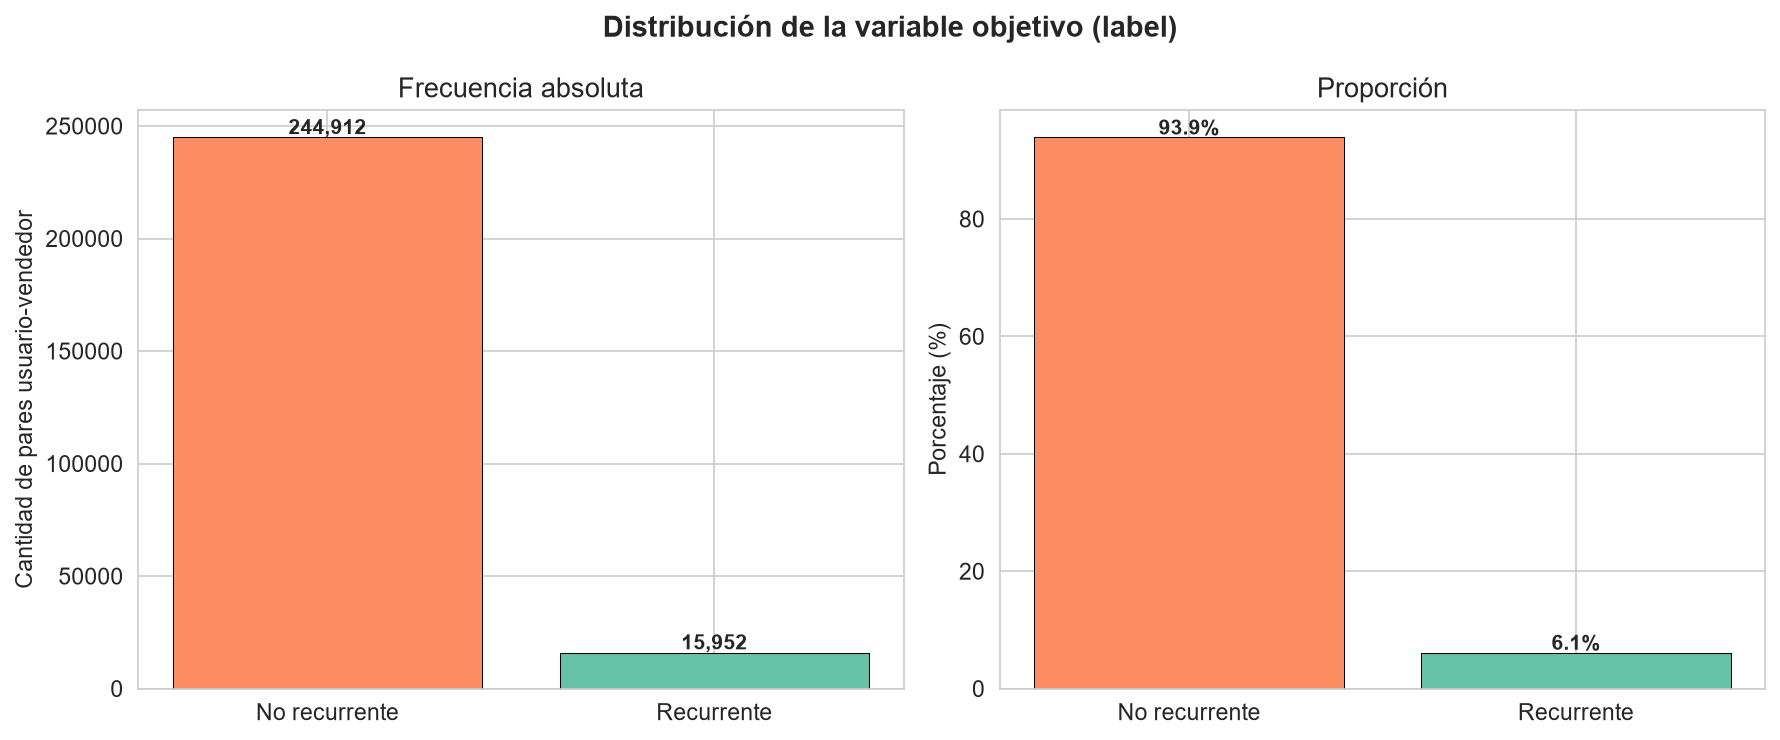

Resumen: 244,912 no recurrentes (93.9%) vs 15,952 recurrentes (6.1%)


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

vc = analitica['label'].value_counts().sort_index()
colors = [COLOR_0, COLOR_1]
nombres = [labels_map[i] for i in vc.index]

# Frecuencia absoluta
axes[0].bar(nombres, vc.values, color=colors, edgecolor='black', linewidth=0.5)
for i, val in enumerate(vc.values):
    axes[0].text(i, val + 1500, f'{val:,}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Frecuencia absoluta')
axes[0].set_ylabel('Cantidad de pares usuario-vendedor')

# Proporción
props = vc / vc.sum() * 100
axes[1].bar(nombres, props.values, color=colors, edgecolor='black', linewidth=0.5)
for i, val in enumerate(props.values):
    axes[1].text(i, val + 0.5, f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Proporción')
axes[1].set_ylabel('Porcentaje (%)')

fig.suptitle('Distribución de la variable objetivo (label)', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, '01_distribucion_recompra.png'))
plt.show()

print(f"Resumen: {vc.iloc[0]:,} no recurrentes ({props.iloc[0]:.1f}%) vs "
      f"{vc.iloc[1]:,} recurrentes ({props.iloc[1]:.1f}%)")

**Interpretación**: Se observa un **desbalance severo** en la variable objetivo. La gran mayoría de los pares usuario-vendedor corresponden a compradores no recurrentes, mientras que los recurrentes representan una minoría. Este desbalance es consistente con la literatura sobre compradores adquiridos durante eventos promocionales masivos como el Double 11, donde la mayoría de los clientes atraídos por descuentos no regresan.

### 8.2 Distribución de rangos de edad

¿Cómo se distribuyen los rangos de edad en los pares usuario-vendedor del conjunto de entrenamiento?

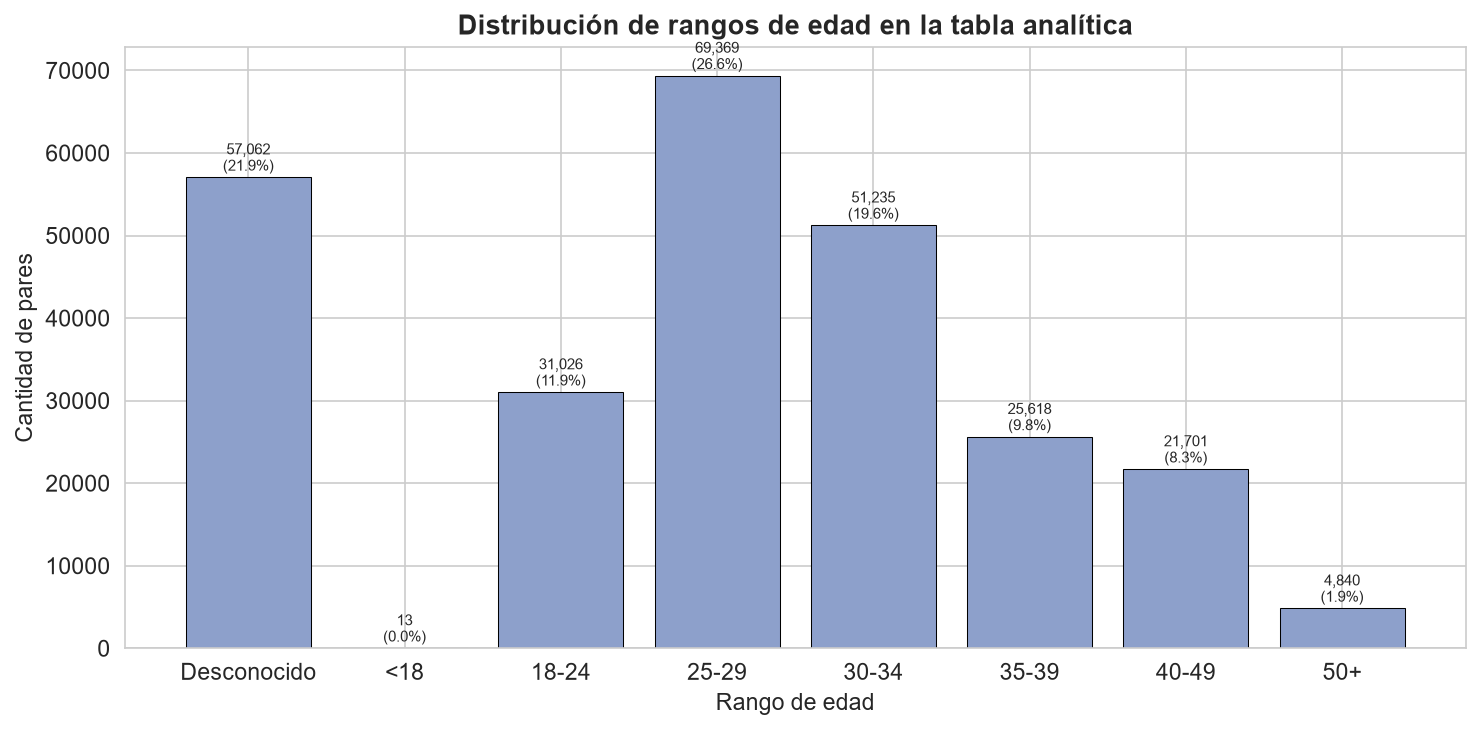

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))

vc_age = analitica['age_range'].value_counts().sort_index()
nombres_edad = [age_labels.get(int(i), str(i)) for i in vc_age.index]

bars = ax.bar(nombres_edad, vc_age.values, color=PALETTE[2], edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, vc_age.values):
    pct = val / vc_age.sum() * 100
    ax.text(bar.get_x() + bar.get_width()/2, val + 800,
            f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=7)

ax.set_title('Distribución de rangos de edad en la tabla analítica', fontweight='bold')
ax.set_xlabel('Rango de edad')
ax.set_ylabel('Cantidad de pares')
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, '02_distribucion_edad.png'))
plt.show()


**Interpretación**: Una proporción significativa de registros tiene edad desconocida (código 0 o NaN original). Los códigos 7 y 8 se consolidan en la categoría analítica `50+`. Entre los rangos conocidos, los grupos de edad media (25–39 años) son los más representados, consistente con el perfil demográfico de usuarios de plataformas de comercio electrónico. Los usuarios menores de 18 y mayores de 50 son minoría.

### 8.3 Distribución de género

¿Cómo se distribuye el género en los pares del conjunto de entrenamiento?

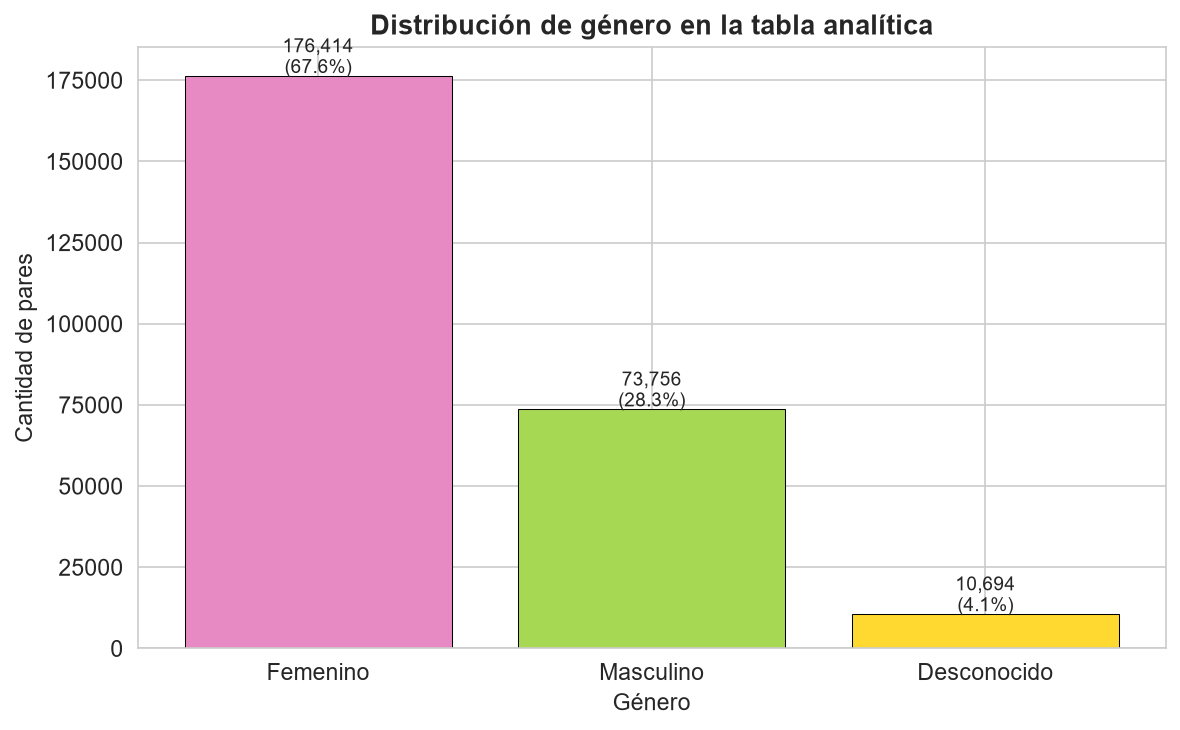

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))

vc_gen = analitica['gender'].value_counts().sort_index()
nombres_gen = [gender_labels.get(int(i), str(i)) for i in vc_gen.index]
colores_gen = [PALETTE[3], PALETTE[4], PALETTE[5]]

bars = ax.bar(nombres_gen, vc_gen.values, color=colores_gen, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, vc_gen.values):
    pct = val / vc_gen.sum() * 100
    ax.text(bar.get_x() + bar.get_width()/2, val + 800,
            f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=9)

ax.set_title('Distribución de género en la tabla analítica', fontweight='bold')
ax.set_xlabel('Género')
ax.set_ylabel('Cantidad de pares')
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, '03_distribucion_genero.png'))
plt.show()

**Interpretación**: La distribución de género muestra una proporción notable de registros con género desconocido. Entre los géneros conocidos, se puede observar la proporción relativa entre femenino y masculino. La alta proporción de datos desconocidos limita las conclusiones demográficas por género.

### 8.4 Variables numéricas derivadas — histogramas

Distribuciones de las métricas de actividad derivadas. Los histogramas se muestran hasta el percentil 99 para facilitar la visualización; los valores extremos se documentan pero no se eliminan.

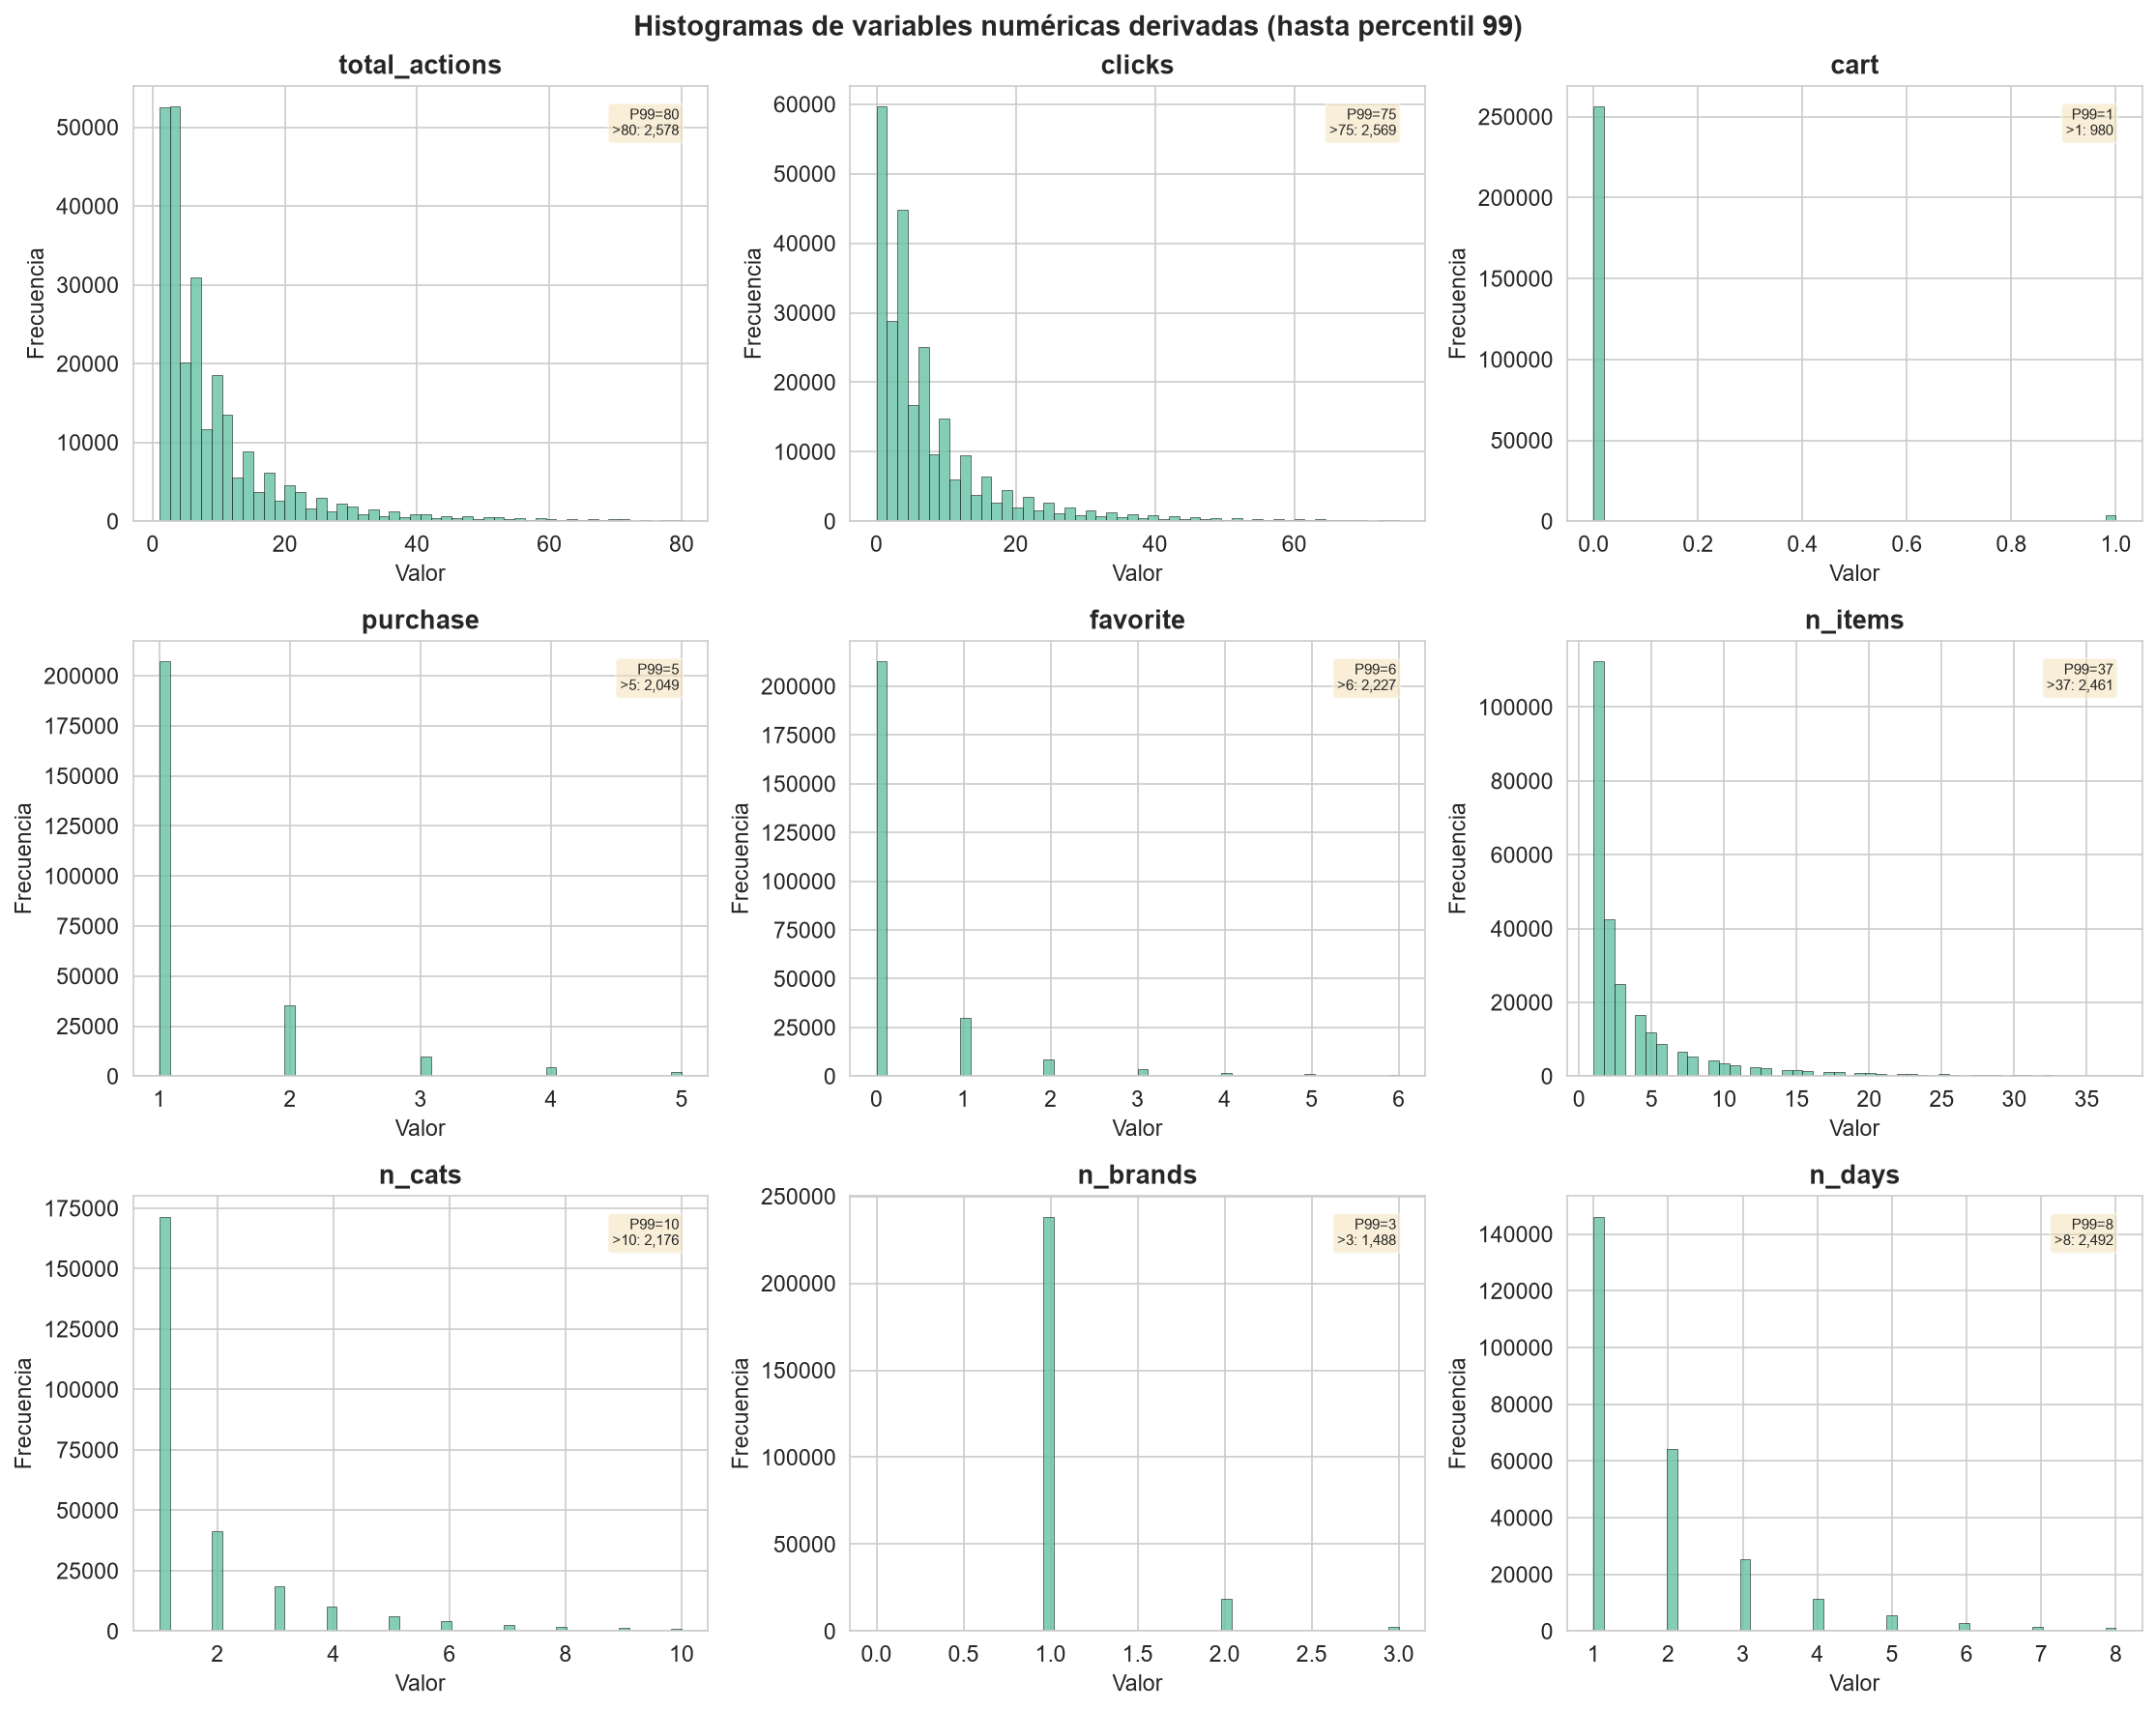

In [20]:
num_vars = ['total_actions', 'clicks', 'cart', 'purchase', 'favorite',
            'n_items', 'n_cats', 'n_brands', 'n_days']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, var in enumerate(num_vars):
    ax = axes[i]
    data = analitica[var]
    p99 = data.quantile(0.99)
    data_plot = data[data <= p99]
    
    ax.hist(data_plot, bins=50, color=PALETTE[0], edgecolor='black',
            linewidth=0.3, alpha=0.8)
    ax.set_title(var, fontweight='bold')
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frecuencia')
    
    n_outliers = (data > p99).sum()
    ax.text(0.95, 0.95, f'P99={p99:.0f}\n>{p99:.0f}: {n_outliers:,}',
            transform=ax.transAxes, ha='right', va='top', fontsize=7,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

fig.suptitle('Histogramas de variables numéricas derivadas (hasta percentil 99)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, '04_histogramas_variables_numericas.png'))
plt.show()

**Interpretación**: Todas las variables numéricas derivadas presentan distribuciones fuertemente sesgadas a la derecha (asimetría positiva). La mayoría de los pares usuario-vendedor tienen poca actividad, mientras que un pequeño porcentaje presenta actividad muy intensa. Esto es típico en datos de comportamiento de usuarios en plataformas digitales, donde una minoría de usuarios genera la mayoría de la actividad.

### 8.5 Variables numéricas — diagramas de caja

Los diagramas de caja permiten visualizar la distribución central y la extensión de los valores atípicos.

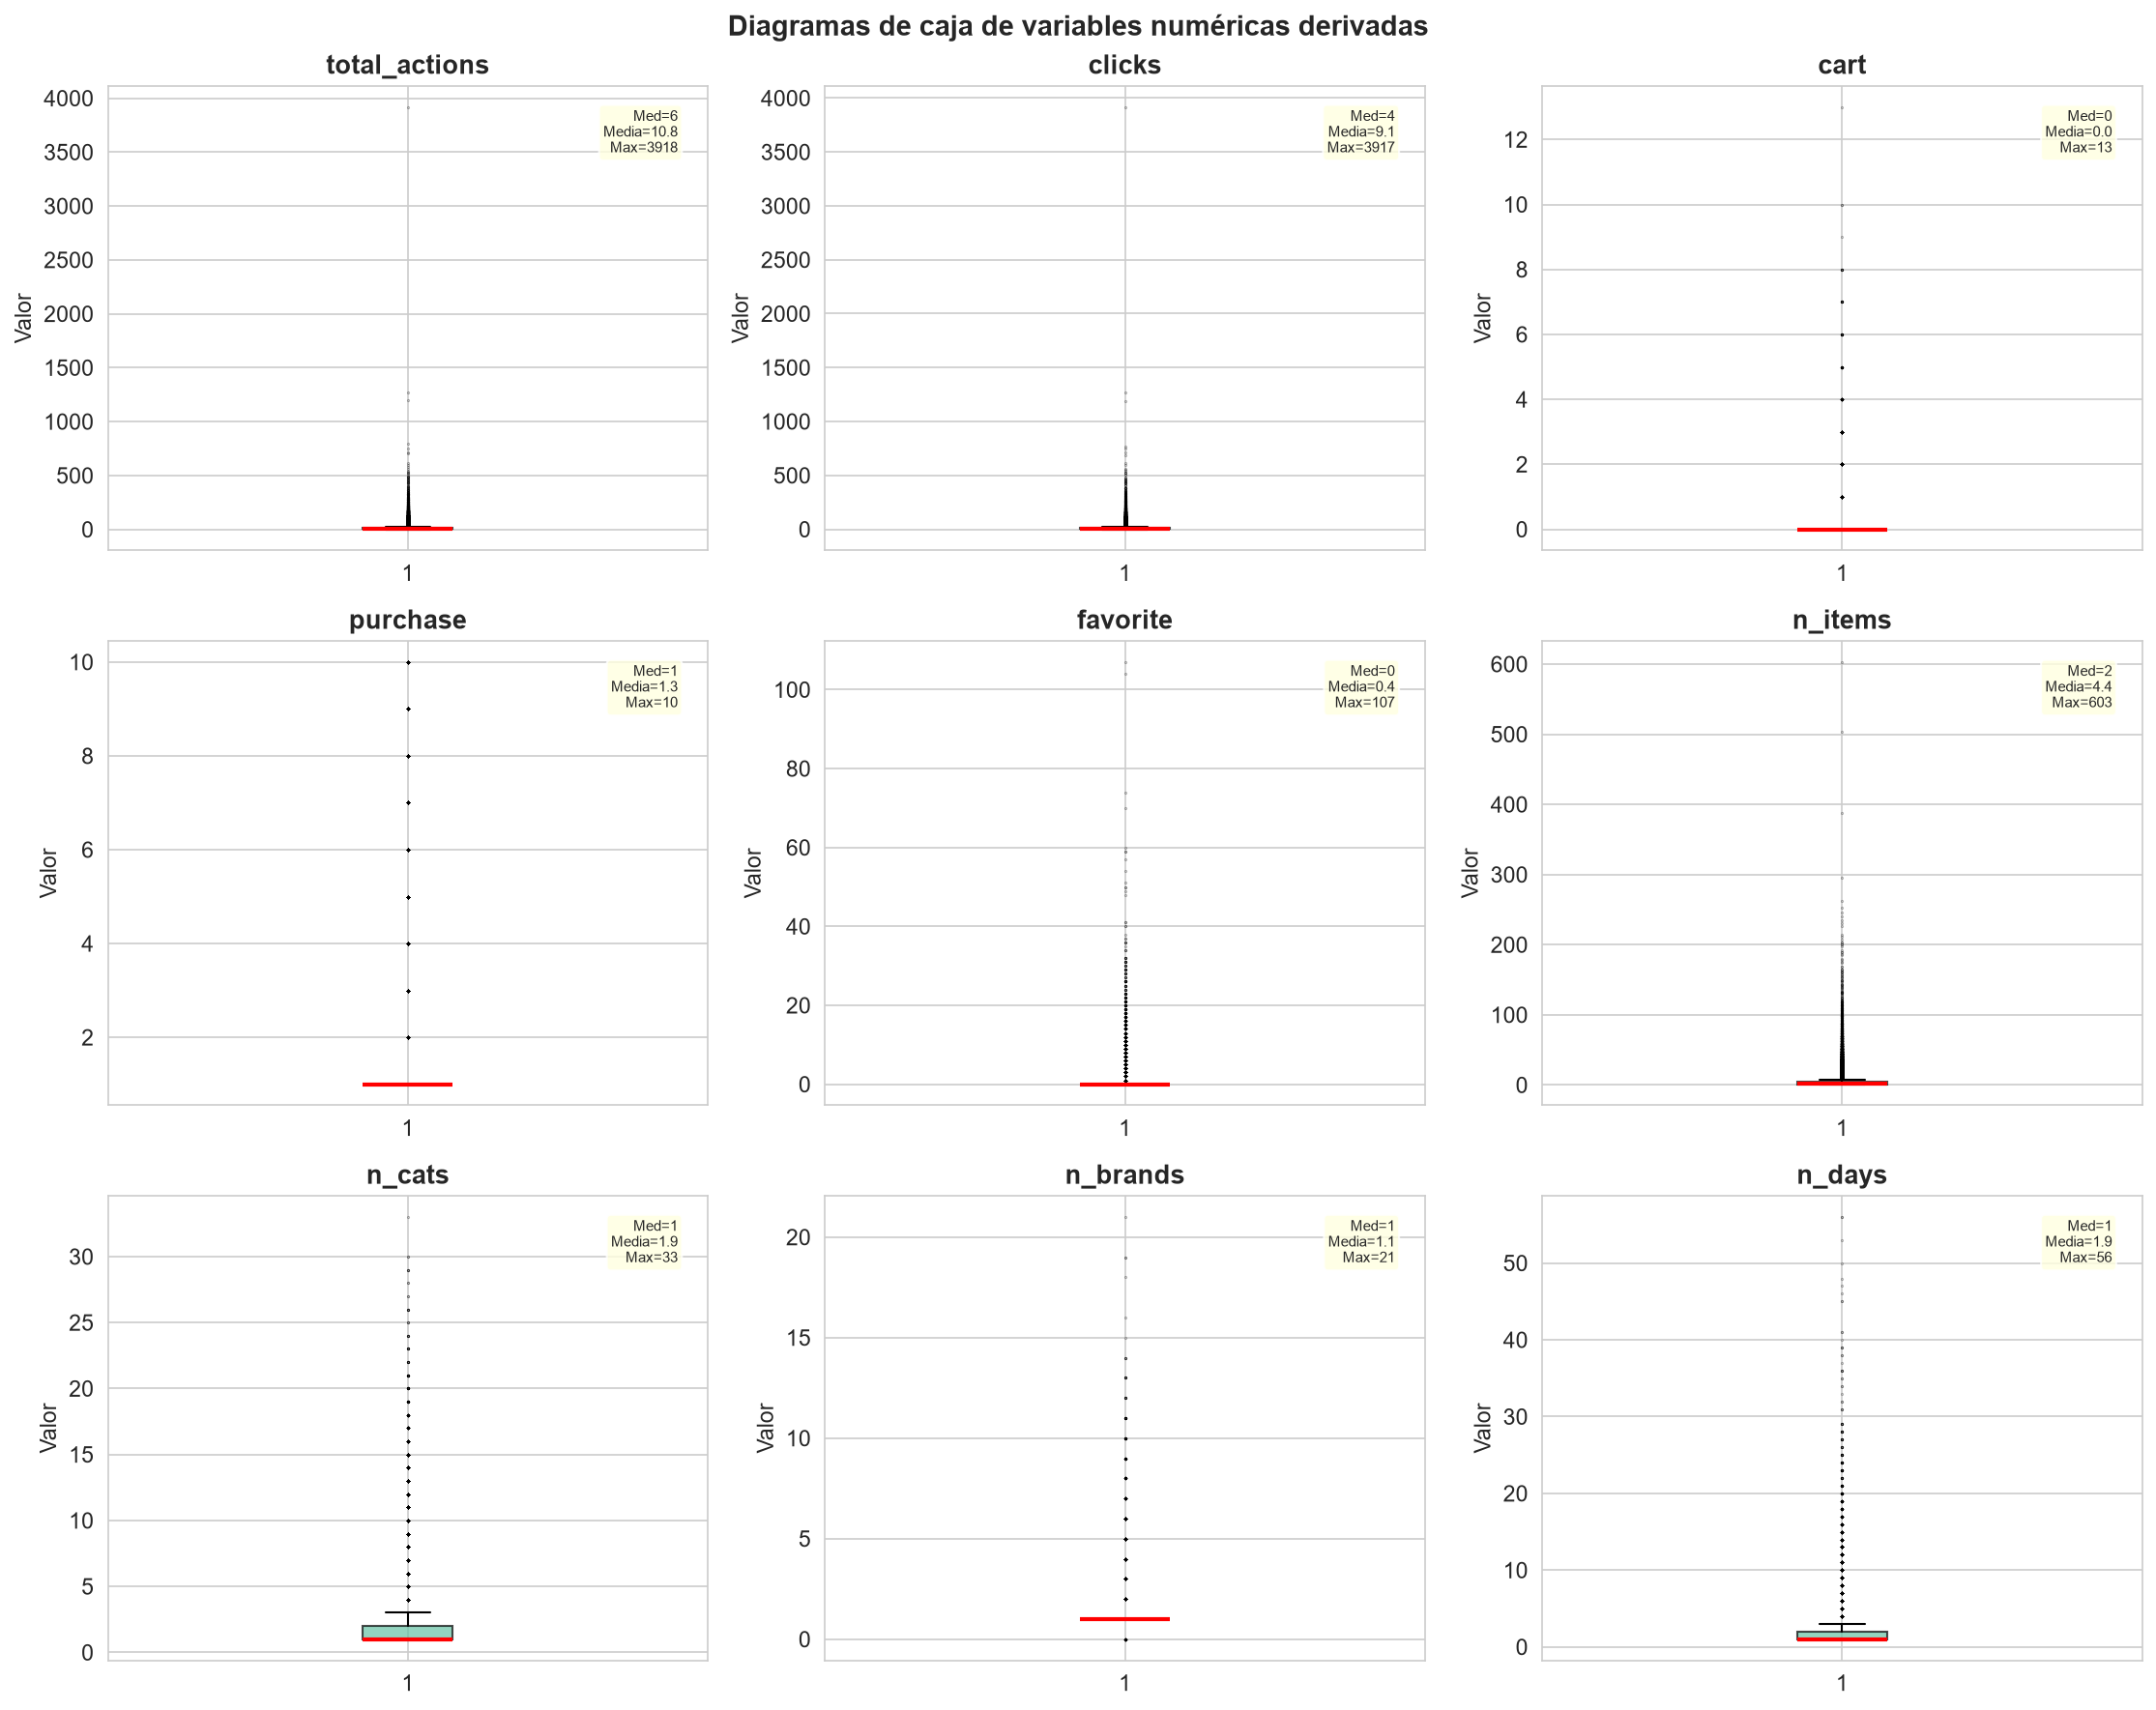

In [21]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, var in enumerate(num_vars):
    ax = axes[i]
    data = analitica[var]
    bp = ax.boxplot(data, vert=True, patch_artist=True,
                    boxprops=dict(facecolor=PALETTE[0], alpha=0.7),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='.', markersize=1, alpha=0.3))
    ax.set_title(var, fontweight='bold')
    ax.set_ylabel('Valor')
    
    stats = data.describe()
    info = f"Med={stats['50%']:.0f}\nMedia={stats['mean']:.1f}\nMax={stats['max']:.0f}"
    ax.text(0.95, 0.95, info, transform=ax.transAxes, ha='right', va='top',
            fontsize=7, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

fig.suptitle('Diagramas de caja de variables numéricas derivadas', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, '05_boxplots_variables_numericas.png'))
plt.show()

**Interpretación**: Los diagramas de caja confirman la presencia de valores atípicos significativos en todas las variables. La caja (IQR) se concentra en valores bajos, y los bigotes y puntos atípicos se extienden considerablemente. Estos outliers representan pares usuario-vendedor con actividad inusualmente alta, que podrían corresponder a compradores de alto volumen, usuarios automatizados o comportamientos de exploración intensiva. **No se eliminan** sin justificación adicional, ya que representan comportamientos reales.

### 8.6 Tabla de estadísticas descriptivas

In [22]:
stats_df = analitica[num_vars].describe().T
stats_df['iqr'] = stats_df['75%'] - stats_df['25%']
stats_df['coef_var'] = (stats_df['std'] / stats_df['mean'] * 100).round(1)

print("Estadísticas descriptivas de variables numéricas derivadas:")
display(stats_df.round(2))

stats_df.to_csv(os.path.join(TAB_DIR, 'estadisticas_descriptivas.csv'))
print("\n✓ Tabla exportada a outputs/tables/estadisticas_descriptivas.csv")

Estadísticas descriptivas de variables numéricas derivadas:


,count,mean,std,min,25%,50%,75%,max,iqr,coef_var
total_actions,260864.0,10.83,19.82,1.0,3.0,6.0,12.0,3918.0,9.0,183.0
clicks,260864.0,9.08,19.03,0.0,2.0,4.0,10.0,3917.0,8.0,209.7
cart,260864.0,0.02,0.21,0.0,0.0,0.0,0.0,13.0,0.0,886.2
purchase,260864.0,1.34,0.86,1.0,1.0,1.0,1.0,10.0,0.0,64.2
favorite,260864.0,0.39,1.43,0.0,0.0,0.0,0.0,107.0,0.0,368.8
n_items,260864.0,4.38,7.95,1.0,1.0,2.0,4.0,603.0,3.0,181.6
n_cats,260864.0,1.88,1.86,1.0,1.0,1.0,2.0,33.0,1.0,99.1
n_brands,260864.0,1.11,0.47,0.0,1.0,1.0,1.0,21.0,0.0,41.8
n_days,260864.0,1.89,1.67,1.0,1.0,1.0,2.0,56.0,1.0,88.3



✓ Tabla exportada a outputs/tables/estadisticas_descriptivas.csv
